In [1]:
# run first time
# import sys
# !{sys.executable} -m pip install "gymnasium[box2d]" imageio statsmodels pyvirtualdisplay tensorflow matplotlib numpy "imageio[ffmpeg]"

In [2]:
import time
from collections import deque, namedtuple

import gymnasium as gym
from gymnasium.envs.box2d.lunar_lander import LunarLander
import math
import numpy as np
import PIL.Image
import tensorflow as tf
import utils

# from pyvirtualdisplay import Display
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.losses import MSE
from tensorflow.keras.optimizers import Adam

In [3]:
class FancyLunarLander(LunarLander):
    def __init__(self, x_range, y_range, **kwargs):
        super().__init__(**kwargs)
        self.max_step_reward = 1.0
        self.max_angle_error = 1.0
        self.safe_x_range = x_range

        self.target_y = 1.0
        self.max_height_error = y_range

    def update_range(self, x_range, y_range):
        self.safe_x_range = x_range
        self.max_height_error = y_range
    
    def step(self, action):
        obs, reward, terminated, truncated, info = super().step(action)

        x, y, vx, vy, angle, angular_v = obs[:6]

        # upside down
        # d1 = abs(angle - 2*math.pi)
        # d2 = abs(angle + 2*math.pi)
        # d = min(d1, d2)
        # angle_reward = 15 * (1 - d / self.max_angle_error) if d < self.max_angle_error else 0.0
        angle_reward = 0

        # horizontal
        if abs(x) <= self.safe_x_range:
            zone_reward = 0.2 * (1 - abs(x) / self.safe_x_range)
        else:
            zone_reward = -2.0 * (abs(x) - self.safe_x_range)

        # vertical
        height_err = abs(y - self.target_y)
        if height_err < self.max_height_error:
            height_reward = 0.5 * (1 - height_err / self.max_height_error)
        else:
            height_reward = -1.0 * (height_err - self.max_height_error)

        # composed rewards
        reward = angle_reward + zone_reward + height_reward

        return obs, reward, terminated, truncated, info

In [4]:
# Set up a virtual display to render the Lunar Lander environment.
# Display(visible=0, size=(840, 480)).start();

# Set the random seed for TensorFlow
tf.random.set_seed(utils.SEED)

In [5]:
MEMORY_SIZE = 100_000     # size of memory buffer
GAMMA = 0.995             # discount factor
ALPHA = 1e-4              # learning rate  
NUM_STEPS_FOR_UPDATE = 4  # perform a learning update every C time steps
MAX_TIME_LIMIT = 500      # max time limit
X_RANGE_INIT = 0.5
Y_RANGE_INIT = 0.3
X_RANGE_END = 0.005
Y_RANGE_END = 0.005

In [6]:
# env = gym.make('LunarLander-v3', render_mode='rgb_array')
env = gym.wrappers.TimeLimit(
    FancyLunarLander(x_range=X_RANGE_INIT, y_range=Y_RANGE_INIT, render_mode='rgb_array'),
    max_episode_steps=MAX_TIME_LIMIT
)

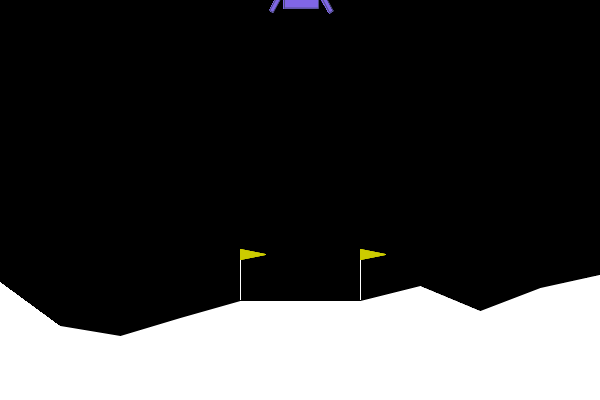

In [7]:
env.reset()
PIL.Image.fromarray(env.render())

In [8]:
state_size = env.observation_space.shape
num_actions = env.action_space.n

print('State Shape:', state_size)
print('Number of actions:', num_actions)

State Shape: (8,)
Number of actions: 4


In [9]:
# Reset the environment and get the initial state.
initial_state = env.reset()

In [10]:
# Select an action
action = 0

# Run a single time step of the environment's dynamics with the given action.
next_state, reward, done, truncated, info = env.step(action)

with np.printoptions(formatter={'float': '{:.3f}'.format}):
    print("Initial State:", initial_state)
    print("Action:", action)
    print("Next State:", next_state)
    print("Reward Received:", reward)
    print("Episode Terminated:", done)
    print("Truncated:", truncated)
    print("Info:", info)

Initial State: (array([-0.002, 1.403, -0.185, -0.334, 0.002, 0.042, 0.000, 0.000],
      dtype=float32), {})
Action: 0
Next State: [-0.004 1.395 -0.185 -0.360 0.004 0.041 0.000 0.000]
Reward Received: 0.10323273
Episode Terminated: False
Truncated: False
Info: {}


In [11]:
# UNQ_C1
# GRADED CELL

# Create the Q-Network
q_network = Sequential([
    ### START CODE HERE ### 
    Input(shape=state_size),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(num_actions, activation='linear')
    ### END CODE HERE ### 
    ])

# Create the target Q^-Network
target_q_network = Sequential([
    ### START CODE HERE ### 
    Input(shape=state_size),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(num_actions, activation='linear')
    ### END CODE HERE ### 
    ])

### START CODE HERE ### 
optimizer = Adam(learning_rate=ALPHA)
### END CODE HERE ###

In [12]:
# UNIT TEST
from public_tests import *

test_network(q_network)
test_network(target_q_network)
test_optimizer(optimizer, ALPHA) 

All tests passed!
All tests passed!
All tests passed!


In [13]:
# Store experiences as named tuples
experience = namedtuple("Experience", field_names=["state", "action", "reward", "next_state", "done"])

In [14]:
# UNQ_C2
# GRADED FUNCTION: calculate_loss

def compute_loss(experiences, gamma, q_network, target_q_network):
    """ 
    Calculates the loss.
    
    Args:
      experiences: (tuple) tuple of ["state", "action", "reward", "next_state", "done"] namedtuples
      gamma: (float) The discount factor.
      q_network: (tf.keras.Sequential) Keras model for predicting the q_values
      target_q_network: (tf.keras.Sequential) Karas model for predicting the targets
          
    Returns:
      loss: (TensorFlow Tensor(shape=(0,), dtype=int32)) the Mean-Squared Error between
            the y targets and the Q(s,a) values.
    """
    
    # Unpack the mini-batch of experience tuples
    states, actions, rewards, next_states, done_vals = experiences
    
    # Compute max Q^(s,a)
    max_qsa = tf.reduce_max(target_q_network(next_states), axis=-1)
    
    # Set y = R if episode terminates, otherwise set y = R + γ max Q^(s,a).
    ### START CODE HERE ### 
    y_targets = rewards + (1.0 - done_vals) * gamma * max_qsa
    ### END CODE HERE ###
    
    # Get the q_values
    q_values = q_network(states)
    q_values = tf.gather_nd(q_values, tf.stack([tf.range(q_values.shape[0]),
                                                tf.cast(actions, tf.int32)], axis=1))
        
    # Compute the loss
    ### START CODE HERE ### 
    loss = MSE(y_targets, q_values)
    ### END CODE HERE ### 
    
    return loss

In [15]:
# UNIT TEST    
test_compute_loss(compute_loss)

All tests passed!


In [16]:
@tf.function
def agent_learn(experiences, gamma):
    """
    Updates the weights of the Q networks.
    
    Args:
      experiences: (tuple) tuple of ["state", "action", "reward", "next_state", "done"] namedtuples
      gamma: (float) The discount factor.
    
    """
    
    # Calculate the loss
    with tf.GradientTape() as tape:
        loss = compute_loss(experiences, gamma, q_network, target_q_network)

    # Get the gradients of the loss with respect to the weights.
    gradients = tape.gradient(loss, q_network.trainable_variables)
    
    # Update the weights of the q_network.
    optimizer.apply_gradients(zip(gradients, q_network.trainable_variables))

    # update the weights of target q_network
    utils.update_target_network(q_network, target_q_network)

In [ ]:
start = time.time()

num_episodes = 4000
max_num_timesteps = 1000

total_point_history = []

num_p_av = 100    # number of total points to use for averaging
epsilon = 1.0     # initial ε value for ε-greedy policy

# Create a memory buffer D with capacity N
memory_buffer = deque(maxlen=MEMORY_SIZE)

# Set the target network weights equal to the Q-Network weights
target_q_network.set_weights(q_network.get_weights())

step = 5
range_step_x = (X_RANGE_INIT - X_RANGE_END) / step
range_step_y = (Y_RANGE_INIT - Y_RANGE_END) / step
for i in range(step+1):   
    curr_x_range = X_RANGE_INIT - range_step_x * i
    curr_y_range = Y_RANGE_INIT - range_step_y * i
    env.unwrapped.update_range(x_range = curr_x_range, y_range = curr_y_range) 
    total_point_history = []
    print(f"\rStep{i}, x range: {curr_x_range}, y range: {curr_y_range}")
    
    for i in range(num_episodes):
        
        # Reset the environment to the initial state and get the initial state
        state, _ = env.reset()
        total_points = 0
        
        for t in range(max_num_timesteps):
            
            # From the current state S choose an action A using an ε-greedy policy
            state_qn = np.expand_dims(state, axis=0)  # state needs to be the right shape for the q_network
            q_values = q_network(state_qn)
            action = utils.get_action(q_values, epsilon)
            
            # Take action A and receive reward R and the next state S'
            next_state, reward, done, _, _ = env.step(action)
            
            # Store experience tuple (S,A,R,S') in the memory buffer.
            # We store the done variable as well for convenience.
            memory_buffer.append(experience(state, action, reward, next_state, done))
            
            # Only update the network every NUM_STEPS_FOR_UPDATE time steps.
            update = utils.check_update_conditions(t, NUM_STEPS_FOR_UPDATE, memory_buffer)
            
            if update:
                # Sample random mini-batch of experience tuples (S,A,R,S') from D
                experiences = utils.get_experiences(memory_buffer)
                
                # Set the y targets, perform a gradient descent step,
                # and update the network weights.
                agent_learn(experiences, GAMMA)
            
            state = next_state.copy()
            total_points += reward
            
            if done:
                break
                
        total_point_history.append(total_points)
        av_latest_points = np.mean(total_point_history[-num_p_av:])
        
        # Update the ε value
        epsilon = utils.get_new_eps(epsilon)
    
        print(f"\rEpisode {i+1} | Total point average of the last {num_p_av} episodes: {av_latest_points:.2f}", end="")
    
        if (i+1) % num_p_av == 0:
            print(f"\rEpisode {i+1} | Total point average of the last {num_p_av} episodes: {av_latest_points:.2f}")
    
        # We will consider that the environment is solved if we get an
        # average of 200 points in the last 100 episodes.
        if av_latest_points >= 200.0:
            print(f"\n\nEnvironment solved in {i+1} episodes!")
            q_network.save('lunar_lander_model.h5')
            break
        
tot_time = time.time() - start

print(f"\nTotal Runtime: {tot_time:.2f} s ({(tot_time/60):.2f} min)")

Step0, x range: 0.5, y range: 0.3
Episode 100 | Total point average of the last 100 episodes: 0.22
Episode 200 | Total point average of the last 100 episodes: 4.205
Episode 300 | Total point average of the last 100 episodes: 3.91
Episode 400 | Total point average of the last 100 episodes: 3.74
Episode 500 | Total point average of the last 100 episodes: 3.93
Episode 600 | Total point average of the last 100 episodes: 3.81
Episode 700 | Total point average of the last 100 episodes: 1.76
Episode 800 | Total point average of the last 100 episodes: 5.42
Episode 900 | Total point average of the last 100 episodes: 7.47
Episode 1000 | Total point average of the last 100 episodes: 9.58
Episode 1100 | Total point average of the last 100 episodes: 11.68
Episode 1200 | Total point average of the last 100 episodes: 11.84
Episode 1300 | Total point average of the last 100 episodes: 11.39
Episode 1400 | Total point average of the last 100 episodes: 12.36
Episode 1500 | Total point average of the last

Episode 2093 | Total point average of the last 100 episodes: 203.83

Environment solved in 2093 episodes!
Step1, x range: 0.401, y range: 0.241


Episode 1 | Total point average of the last 100 episodes: 452.29

Environment solved in 1 episodes!
Step2, x range: 0.302, y range: 0.182


Episode 1 | Total point average of the last 100 episodes: 432.51

Environment solved in 1 episodes!
Step3, x range: 0.20299999999999996, y range: 0.123


Episode 1 | Total point average of the last 100 episodes: 315.45

Environment solved in 1 episodes!
Step4, x range: 0.10399999999999998, y range: 0.064
Episode 100 | Total point average of the last 100 episodes: 22.20
Episode 200 | Total point average of the last 100 episodes: 91.42
Episode 300 | Total point average of the last 100 episodes: -1.727
Episode 387 | Total point average of the last 100 episodes: 196.24

Episode 388 | Total point average of the last 100 episodes: 200.88

Environment solved in 388 episodes!
Step5, x range: 0.0050000000000000044, y range: 0.0050000000000000044
Episode 55 | Total point average of the last 100 episodes: -46.58

In [ ]:
# Plot the point history
utils.plot_history(total_point_history)

In [ ]:
# Suppress warnings from imageio
import logging
logging.getLogger().setLevel(logging.ERROR)

In [ ]:
filename = "./videos/lunar_lander.mp4"

utils.create_video(filename, env, q_network)
utils.embed_mp4(filename)